# Imports


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import os
from tqdm import tqdm
import matplotlib.pyplot as plt
import copy
WORD_SIZE = 16
MASK_VAL = 2 ** WORD_SIZE - 1
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Running on {DEVICE}.")

Running on cuda.


# Speck32/64 implementation

In [2]:
def rol(x, r):
    return ((x << r) & MASK_VAL) | (x >> (WORD_SIZE - r))


def ror(x, r):
    return ((x >> r) | (x << (WORD_SIZE - r))) & MASK_VAL


def enc_one_round(p, k):
    c0, c1 = p[0], p[1]
    c0 = ror(c0, 7)
    c0 = (c0 + c1) & MASK_VAL
    c0 = c0 ^ k
    c1 = rol(c1, 2)
    c1 = c1 ^ c0
    return c0, c1


def dec_one_round(c, k):
    c0, c1 = c[0], c[1]
    c1 = c1 ^ c0
    c1 = ror(c1, 2)
    c0 = c0 ^ k
    c0 = (c0 - c1) & MASK_VAL
    c0 = rol(c0, 7)
    return c0, c1


def expand_key(k, t):
    ks = [0 for _ in range(t)]
    ks[0] = k[len(k) - 1]
    l = list(reversed(k[:len(k) - 1]))
    for i in range(t - 1):
        l[i % 3], ks[i + 1] = enc_one_round((l[i % 3], ks[i]), i)
    return ks


def encrypt_pair(p, ks):
    x, y = p[0], p[1]
    for k in ks:
        x, y = enc_one_round((x, y), k)
    return x, y


def dec_one_round_vec(c0, c1, k):
    # Vectorized decryption for numpy arrays
    c1 = c1 ^ c0
    c1 = ((c1 >> 2) | (c1 << 14)) & MASK_VAL
    c0 = c0 ^ k
    c0 = (c0 - c1) & MASK_VAL
    c0 = ((c0 << 7) | (c0 >> 9)) & MASK_VAL
    return c0, c1

def extract_features_2024(c0l, c0r, c1l, c1r):
    # Features from 2024 Paper Lemma 1: (Left1^Left2, Left1^Right1, Left1^Right2)
    f1 = c0l ^ c1l
    f2 = c0l ^ c0r
    f3 = c0l ^ c1r

    n_samples = c0l.shape[0] if isinstance(c0l, np.ndarray) else c0l.size(0)
    X_bin = np.zeros((n_samples, 3, 16), dtype=np.float32)

    for i in range(16):
        bit_mask = 1 << i
        X_bin[:, 0, i] = (f1 & bit_mask) >> i
        X_bin[:, 1, i] = (f2 & bit_mask) >> i
        X_bin[:, 2, i] = (f3 & bit_mask) >> i

    return X_bin


def make_train_data(n_samples, rounds, diff=(0x0040, 0x0000)):
    keys = np.frombuffer(os.urandom(n_samples * 8), dtype=np.uint16).reshape(n_samples, 4)
    p0l = np.frombuffer(os.urandom(n_samples * 2), dtype=np.uint16)
    p0r = np.frombuffer(os.urandom(n_samples * 2), dtype=np.uint16)
    p1l = p0l ^ diff[0]
    p1r = p0r ^ diff[1]

    ks = np.zeros((n_samples, rounds), dtype=np.uint16)
    l = [keys[:, 0], keys[:, 1], keys[:, 2]]
    ks[:, 0] = keys[:, 3]
    for i in range(rounds - 1):
        l[i % 3] = ((l[i % 3] >> 7) | (l[i % 3] << 9)) & MASK_VAL
        l[i % 3] = (l[i % 3] + ks[:, i]) & MASK_VAL
        l[i % 3] = l[i % 3] ^ i
        ks[:, i + 1] = ((ks[:, i] << 2) | (ks[:, i] >> 14)) & MASK_VAL
        ks[:, i + 1] = ks[:, i + 1] ^ l[i % 3]

    c0l, c0r = p0l.copy(), p0r.copy()
    c1l, c1r = p1l.copy(), p1r.copy()

    for i in range(rounds):
        ki = ks[:, i]
        c0l = ((c0l >> 7) | (c0l << 9)) & MASK_VAL
        c0l = (c0l + c0r) & MASK_VAL
        c0l ^= ki
        c0r = ((c0r << 2) | (c0r >> 14)) & MASK_VAL
        c0r ^= c0l
        c1l = ((c1l >> 7) | (c1l << 9)) & MASK_VAL
        c1l = (c1l + c1r) & MASK_VAL
        c1l ^= ki
        c1r = ((c1r << 2) | (c1r >> 14)) & MASK_VAL
        c1r ^= c1l

    Y = np.frombuffer(os.urandom(n_samples), dtype=np.uint8) & 1
    rand_mask = (Y == 0)
    n_rand = np.sum(rand_mask)
    c1l[rand_mask] = np.frombuffer(os.urandom(n_rand * 2), dtype=np.uint16)
    c1r[rand_mask] = np.frombuffer(os.urandom(n_rand * 2), dtype=np.uint16)

    X = extract_features_2024(c0l, c0r, c1l, c1r)
    return torch.tensor(X), torch.tensor(Y, dtype=torch.float32)



# CNN

In [3]:
class ResBlock(nn.Module):
    def __init__(self, channels, kernel_size=3):
        super(ResBlock, self).__init__()
        self.conv1 = nn.Conv1d(channels, 32, kernel_size, padding=1)
        self.bn1 = nn.BatchNorm1d(32)
        self.conv2 = nn.Conv1d(32, channels, kernel_size, padding=1)
        self.bn2 = nn.BatchNorm1d(channels)
        self.relu = nn.ReLU()

    def forward(self, x):
        res = x
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.relu(self.bn2(self.conv2(x)))
        x = x + res
        return x


class ImprovedCNN(nn.Module):
    def __init__(self, depth=10):
        super(ImprovedCNN, self).__init__()
        self.in_channels = 3
        self.res_tower = nn.Sequential(*[ResBlock(self.in_channels) for _ in range(depth)])
        self.fc1 = nn.Linear(3 * 16, 64)
        self.bn1 = nn.BatchNorm1d(64)
        self.fc2 = nn.Linear(64, 64)
        self.bn2 = nn.BatchNorm1d(64)
        self.out = nn.Linear(64, 1)
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.res_tower(x)
        x = x.view(x.size(0), -1)
        x = self.relu(self.bn1(self.fc1(x)))
        x = self.relu(self.bn2(self.fc2(x)))
        x = self.sigmoid(self.out(x))
        return x

# Training function

In [4]:
def train_dnd(rounds, n_epochs=200, depth=10, batch_size=5000, save_dir="light_models"):
    model = ImprovedCNN(depth=depth).to(DEVICE)

    loss_fn = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)

    TOTAL_SAMPLES = 10**7
    VAL_SIZE = 10**6
    TRAIN_SIZE = TOTAL_SAMPLES - VAL_SIZE
    steps_per_epoch = TRAIN_SIZE // batch_size

    scheduler = optim.lr_scheduler.OneCycleLR(
        optimizer,
        max_lr=1e-3,
        steps_per_epoch=steps_per_epoch,
        epochs=n_epochs,
        pct_start=0.1
    )

    os.makedirs(save_dir, exist_ok=True)
    save_path = os.path.join(save_dir, f"dnd_speck32_r{rounds}_d{depth}.pt")

    print(f"Training {rounds}-round DND (Depth {depth}) for {n_epochs} epochs...")
    print(f"Data: {TRAIN_SIZE} Train / {VAL_SIZE} Val per epoch.")
    print(f"Saving best model to: {save_path}")

    history = {
        "train_loss": [], "val_loss": [],
        "train_acc": [], "val_acc": []
    }

    best_val_acc = 0.0
    best_model_state = copy.deepcopy(model.state_dict())

    for epoch in range(n_epochs):
        X_all, Y_all = make_train_data(TOTAL_SAMPLES, rounds)

        X_train, X_val = X_all[:TRAIN_SIZE], X_all[TRAIN_SIZE:]
        Y_train, Y_val = Y_all[:TRAIN_SIZE], Y_all[TRAIN_SIZE:]

        train_ds = TensorDataset(X_train.to(DEVICE), Y_train.to(DEVICE))
        train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)

        model.train()
        epoch_train_loss = 0.0
        epoch_train_acc = 0.0

        iter_wrapper = tqdm(train_loader, desc=f"Epoch {epoch + 1} [Train]")

        for xb, yb in iter_wrapper:
            optimizer.zero_grad()
            out = model(xb).squeeze()
            loss = loss_fn(out, yb)
            loss.backward()
            optimizer.step()
            scheduler.step()

            epoch_train_loss += loss.item()
            acc = ((out > 0.5) == (yb > 0.5)).float().mean().item()
            epoch_train_acc += acc

        avg_train_loss = epoch_train_loss / len(train_loader)
        avg_train_acc = epoch_train_acc / len(train_loader)

        model.eval()
        with torch.no_grad():
            val_ds = TensorDataset(X_val.to(DEVICE), Y_val.to(DEVICE))
            val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)

            val_loss_sum = 0.0
            val_acc_sum = 0.0

            for xb, yb in val_loader:
                out = model(xb).squeeze()
                loss = loss_fn(out, yb)
                val_loss_sum += loss.item()
                acc = ((out > 0.5) == (yb > 0.5)).float().mean().item()
                val_acc_sum += acc

            avg_val_loss = val_loss_sum / len(val_loader)
            avg_val_acc = val_acc_sum / len(val_loader)

        history["train_loss"].append(avg_train_loss)
        history["val_loss"].append(avg_val_loss)
        history["train_acc"].append(avg_train_acc)
        history["val_acc"].append(avg_val_acc)

        if avg_val_acc > best_val_acc:
            best_val_acc = avg_val_acc
            best_model_state = copy.deepcopy(model.state_dict())

            ckpt = {
                "rounds": rounds,
                "depth": depth,
                "epoch": epoch + 1,
                "best_val_acc": best_val_acc,
                "model_state_dict": best_model_state,
            }
            torch.save(ckpt, save_path)

        print(f"  Train Loss: {avg_train_loss:.5f} | Val Loss: {avg_val_loss:.5f}")
        print(f"  Train Acc:  {avg_train_acc:.4f}  | Val Acc:  {avg_val_acc:.4f}")

    print(f"\nTraining Complete. Best Validation Accuracy: {best_val_acc:.4f}")
    model.load_state_dict(best_model_state)
    plot_training_history(history)
    return model

def train_batches(model, optimizer, loss_fn, rounds, n_batches, batch_size, diff, desc, history=None):
    """
    Train for n_batches iterations using tqdm. Updates optional history dict with
    keys: step, loss, acc, lr. Returns a summary dict with average loss/acc and
    number of steps performed.
    """
    model.train()

    total_loss = 0.0
    total_acc = 0.0

    # initialize starting step
    if history is not None:
        last_step = history["step"][-1] if history["step"] else -1
    else:
        last_step = -1

    pbar = tqdm(range(n_batches), desc=desc)
    for i in pbar:
        X, Y = make_train_data(batch_size, rounds, diff=diff)
        X, Y = X.to(DEVICE), Y.to(DEVICE)

        optimizer.zero_grad()
        out = model(X).squeeze()
        loss = loss_fn(out, Y)
        loss.backward()
        optimizer.step()

        acc = ((out > 0.5) == (Y > 0.5)).float().mean().item()
        lr = optimizer.param_groups[0]["lr"]

        total_loss += loss.item()
        total_acc += acc

        if history is not None:
            step = last_step + 1
            last_step = step
            history["step"].append(step)
            history["loss"].append(loss.item())
            history["acc"].append(acc)
            history["lr"].append(lr)

        pbar.set_postfix(loss=f"{loss.item():.4f}", acc=f"{acc:.3f}", lr=f"{lr:.1e}")

    n_done = n_batches
    avg_loss = total_loss / n_done if n_done else float("nan")
    avg_acc = total_acc / n_done if n_done else float("nan")

    print(f"{desc} Completed: Avg Loss: {avg_loss:.5f} | Avg Acc: {avg_acc:.4f} | Batches: {n_done}")

    return {"avg_loss": avg_loss, "avg_acc": avg_acc, "n_steps": n_done}


def train_N8_from_N7(model_N7, save_path):
    """
    Train N8 from N7. Uses train_batches which now prints and returns summaries.
    Prints stage summaries and saves final checkpoint (already done).
    """
    model = ImprovedCNN(depth=1).to(DEVICE)
    model.load_state_dict(model_N7.state_dict())

    loss_fn = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-5)

    history = {
        "step": [],
        "loss": [],
        "acc": [],
        "lr": []
    }

    print("Starting N8 training from N7...")

    stage1_stats = {"avg_loss": [], "avg_acc": []}
    for epoch in range(10):
        desc = f"N8 pretrain epoch {epoch+1}/10"
        stats = train_batches(
            model,
            optimizer,
            loss_fn,
            rounds=5,
            n_batches=(10**7) // 5000,
            batch_size=5000,
            diff=(0x8000, 0x840a),
            desc=desc,
            history=history
        )
        stage1_stats["avg_loss"].append(stats["avg_loss"])
        stage1_stats["avg_acc"].append(stats["avg_acc"])
        print(f"  Epoch {epoch+1}: Avg Loss {stats['avg_loss']:.5f} | Avg Acc {stats['avg_acc']:.4f}")

    print(f"Stage 1 complete. Mean Loss: {np.mean(stage1_stats['avg_loss']):.5f} | Mean Acc: {np.mean(stage1_stats['avg_acc']):.4f}")

    stage2_stats = []
    for lr in [1e-4, 1e-5, 1e-6]:
        optimizer.param_groups[0]["lr"] = lr
        desc = f"N8 8r pass lr={lr}"
        stats = train_batches(
            model,
            optimizer,
            loss_fn,
            rounds=8,
            n_batches=(10**9) // 10000,
            batch_size=10000,
            diff=(0x0040, 0x0000),
            desc=desc,
            history=history
        )
        stage2_stats.append((lr, stats))
        print(f"  LR {lr:.0e}: Avg Loss {stats['avg_loss']:.5f} | Avg Acc {stats['avg_acc']:.4f}")

    torch.save(
        {
            "rounds": 8,
            "depth": 1,
            "model_state_dict": model.state_dict(),
            "history": history
        },
        save_path
    )

    s2_losses = [s["avg_loss"] for _, s in stage2_stats]
    s2_accs = [s["avg_acc"] for _, s in stage2_stats]
    print(f"Stage 2 complete. Mean Loss: {np.mean(s2_losses):.5f} | Mean Acc: {np.mean(s2_accs):.4f}")

    plot_training_history_N8(history)
    return model


def plot_training_history(history):
    epochs = range(1, len(history['train_loss']) + 1)

    plt.figure(figsize=(12, 5))

    # Plot Loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history['train_loss'], label='Train Loss')
    plt.plot(epochs, history['val_loss'], label='Val Loss')
    plt.title('Loss over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('MSE Loss')
    plt.legend()
    plt.grid(True)

    # Plot Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history['train_acc'], label='Train Acc')
    plt.plot(epochs, history['val_acc'], label='Val Acc')
    plt.title('Accuracy over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

def plot_training_history_N8(history):
    steps = history["step"]

    plt.figure(figsize=(12, 5))

    # Loss
    plt.subplot(1, 2, 1)
    plt.plot(steps, history["loss"])
    plt.title("N8 Training Loss")
    plt.xlabel("Training Step")
    plt.ylabel("MSE Loss")
    plt.grid(True)

    # Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(steps, history["acc"])
    plt.title("N8 Training Accuracy")
    plt.xlabel("Training Step")
    plt.ylabel("Accuracy")
    plt.grid(True)

    plt.tight_layout()
    plt.show()


# Scenario generation

In [5]:
def expand_key(key, rounds):
    """
    Speck32/64 Key Schedule.
    Expands a 64-bit key (4x16-bit words) into 'rounds' round keys.
    """
    # Parse key into 4 words (k0..k3)
    k = [key[i] for i in range(4)]

    # Run key schedule
    ks = [0] * rounds
    ks[0] = k[0]

    # l holds the other 3 words
    l = k[1:]

    alpha, beta = 7, 2

    for i in range(rounds - 1):

        l_curr = l[0]
        # ROR l_curr by alpha (7)
        l_curr = ((l_curr >> 7) | (l_curr << 9)) & 0xFFFF
        l_curr = (l_curr + ks[i]) & 0xFFFF
        l_curr = l_curr ^ i

        # Shift l array
        l = l[1:] + [l_curr]

        k_curr = ks[i]
        # ROL k_curr by beta (2)
        k_curr = ((k_curr << 2) | (k_curr >> 14)) & 0xFFFF
        k_curr = k_curr ^ l_curr

        ks[i+1] = k_curr

    return ks

def encrypt_vectorized(p_left, p_right, ks):
    """
    Encrypts a batch of plaintexts using Speck32/64.
    p_left, p_right: Numpy arrays of uint16
    ks: List of round keys
    """
    x = p_left.copy()
    y = p_right.copy()

    # Constants
    alpha, beta = 7, 2

    for k in ks:
        # x = (ROR(x, alpha) + y) ^ k
        x = ((x >> alpha) | (x << (16 - alpha))) & 0xFFFF
        x = (x + y) & 0xFFFF
        x = x ^ k

        # y = ROL(y, beta) ^ x
        y = ((y << beta) | (y >> (16 - beta))) & 0xFFFF
        y = y ^ x

    return x, y


# Save models

Training 5-round DND (Depth 10) for 200 epochs...
Data: 9000000 Train / 1000000 Val per epoch.
Saving best model to: light_models\dnd_speck32_r5_d10.pt


Epoch 1 [Train]: 100%|██████████| 1800/1800 [03:11<00:00,  9.39it/s]


  Train Loss: 0.15198 | Val Loss: 0.12234
  Train Acc:  0.7906  | Val Acc:  0.8417


Epoch 2 [Train]: 100%|██████████| 1800/1800 [03:18<00:00,  9.08it/s]


  Train Loss: 0.11497 | Val Loss: 0.11026
  Train Acc:  0.8516  | Val Acc:  0.8583


...

  Train Loss: 0.05501 | Val Loss: 0.05534
  Train Acc:  0.9270  | Val Acc:  0.9265


Epoch 199 [Train]: 100%|██████████| 1800/1800 [03:16<00:00,  9.17it/s]


  Train Loss: 0.05492 | Val Loss: 0.05511
  Train Acc:  0.9271  | Val Acc:  0.9271


Epoch 200 [Train]: 100%|██████████| 1800/1800 [03:16<00:00,  9.16it/s]


  Train Loss: 0.05508 | Val Loss: 0.05517
  Train Acc:  0.9268  | Val Acc:  0.9270

Training Complete. Best Validation Accuracy: 0.9274


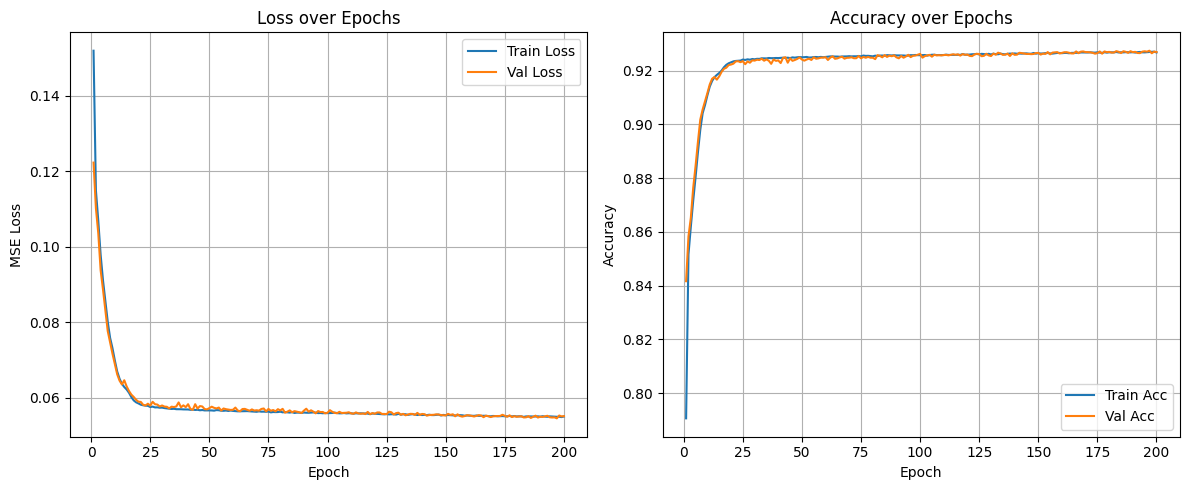

Training 6-round DND (Depth 10) for 200 epochs...
Data: 9000000 Train / 1000000 Val per epoch.
Saving best model to: light_models\dnd_speck32_r6_d10.pt


Epoch 1 [Train]: 100%|██████████| 1800/1800 [03:14<00:00,  9.25it/s]


  Train Loss: 0.23222 | Val Loss: 0.22031
  Train Acc:  0.6054  | Val Acc:  0.6359


Epoch 2 [Train]: 100%|██████████| 1800/1800 [03:18<00:00,  9.06it/s]


  Train Loss: 0.21066 | Val Loss: 0.20338
  Train Acc:  0.6634  | Val Acc:  0.6838


...

  Train Loss: 0.14638 | Val Loss: 0.14656
  Train Acc:  0.7873  | Val Acc:  0.7870


Epoch 199 [Train]: 100%|██████████| 1800/1800 [02:47<00:00, 10.76it/s]


  Train Loss: 0.14652 | Val Loss: 0.14677
  Train Acc:  0.7872  | Val Acc:  0.7869


Epoch 200 [Train]: 100%|██████████| 1800/1800 [02:47<00:00, 10.73it/s]


  Train Loss: 0.14653 | Val Loss: 0.14676
  Train Acc:  0.7872  | Val Acc:  0.7868

Training Complete. Best Validation Accuracy: 0.7879


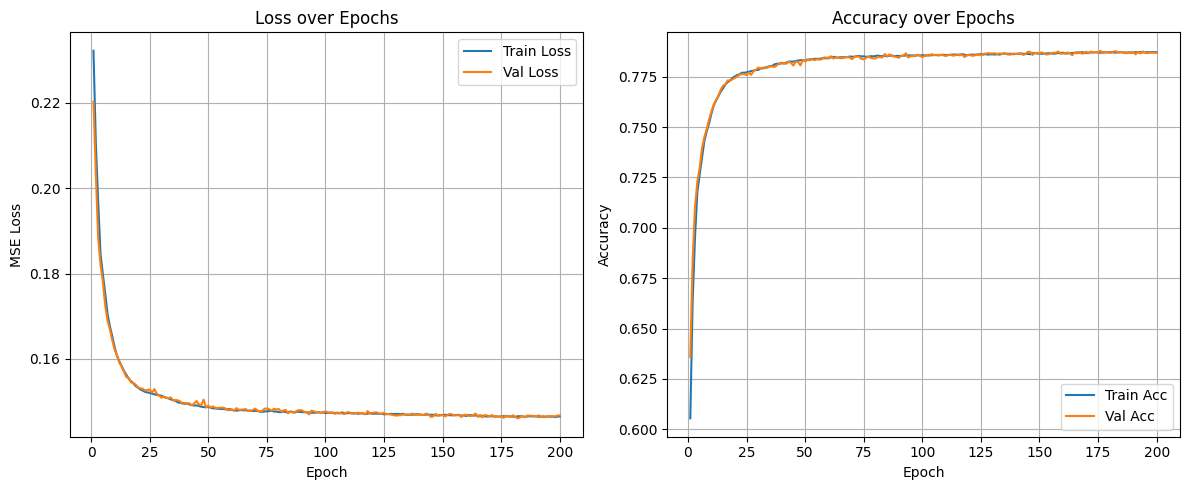

Training 7-round DND (Depth 1) for 300 epochs...
Data: 9000000 Train / 1000000 Val per epoch.
Saving best model to: light_models\dnd_speck32_r7_d1.pt


Epoch 1 [Train]: 100%|██████████| 1800/1800 [01:51<00:00, 16.21it/s]


  Train Loss: 0.25151 | Val Loss: 0.25057
  Train Acc:  0.5008  | Val Acc:  0.5011


Epoch 2 [Train]: 100%|██████████| 1800/1800 [01:51<00:00, 16.13it/s]


  Train Loss: 0.25040 | Val Loss: 0.25028
  Train Acc:  0.5008  | Val Acc:  0.5006


...

  Train Loss: 0.24571 | Val Loss: 0.24564
  Train Acc:  0.5504  | Val Acc:  0.5506


Epoch 299 [Train]: 100%|██████████| 1800/1800 [02:33<00:00, 11.69it/s]


  Train Loss: 0.24568 | Val Loss: 0.24559
  Train Acc:  0.5506  | Val Acc:  0.5511


Epoch 300 [Train]: 100%|██████████| 1800/1800 [02:31<00:00, 11.85it/s]


  Train Loss: 0.24569 | Val Loss: 0.24566
  Train Acc:  0.5504  | Val Acc:  0.5506

Training Complete. Best Validation Accuracy: 0.5514


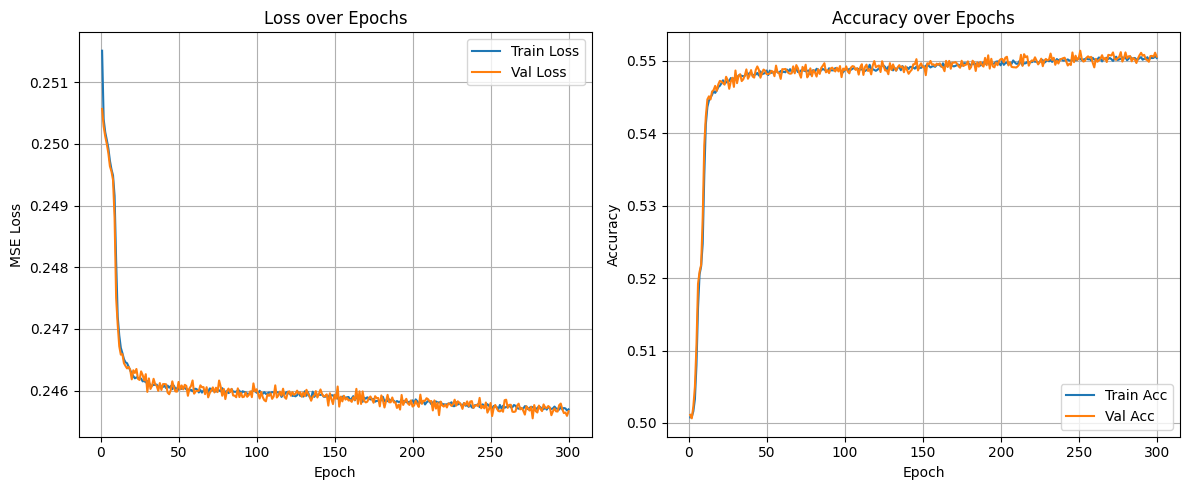

In [6]:
# Train N5 / N6
model_N5 = train_dnd(5, n_epochs=200, depth=10)
model_N6 = train_dnd(6, n_epochs=200, depth=10)

# Train N7
model_N7 = train_dnd(7, n_epochs=300, depth=1)

## N8


Starting N8 training from N7...


N8 pretrain epoch 1/10: 100%|██████████| 2000/2000 [00:15<00:00, 128.23it/s, acc=0.497, loss=0.2501, lr=1.0e-04]


N8 pretrain epoch 1/10 Completed: Avg Loss: 0.25043 | Avg Acc: 0.4999 | Batches: 2000
  Epoch 1: Avg Loss 0.25043 | Avg Acc 0.4999


N8 pretrain epoch 2/10: 100%|██████████| 2000/2000 [00:15<00:00, 129.66it/s, acc=0.504, loss=0.2501, lr=1.0e-04]


N8 pretrain epoch 2/10 Completed: Avg Loss: 0.25006 | Avg Acc: 0.5000 | Batches: 2000
  Epoch 2: Avg Loss 0.25006 | Avg Acc 0.5000


...

N8 8r pass lr=0.0001 Completed: Avg Loss: 0.25000 | Avg Acc: 0.5000 | Batches: 100000
  LR 1e-04: Avg Loss 0.25000 | Avg Acc 0.5000


N8 8r pass lr=1e-05: 100%|██████████| 100000/100000 [36:03<00:00, 46.21it/s, acc=0.495, loss=0.2500, lr=1.0e-05]


N8 8r pass lr=1e-05 Completed: Avg Loss: 0.25000 | Avg Acc: 0.5000 | Batches: 100000
  LR 1e-05: Avg Loss 0.25000 | Avg Acc 0.5000


N8 8r pass lr=1e-06: 100%|██████████| 100000/100000 [36:04<00:00, 46.19it/s, acc=0.504, loss=0.2500, lr=1.0e-06]


N8 8r pass lr=1e-06 Completed: Avg Loss: 0.25000 | Avg Acc: 0.5000 | Batches: 100000
  LR 1e-06: Avg Loss 0.25000 | Avg Acc 0.5000
Stage 2 complete. Mean Loss: 0.25000 | Mean Acc: 0.5000


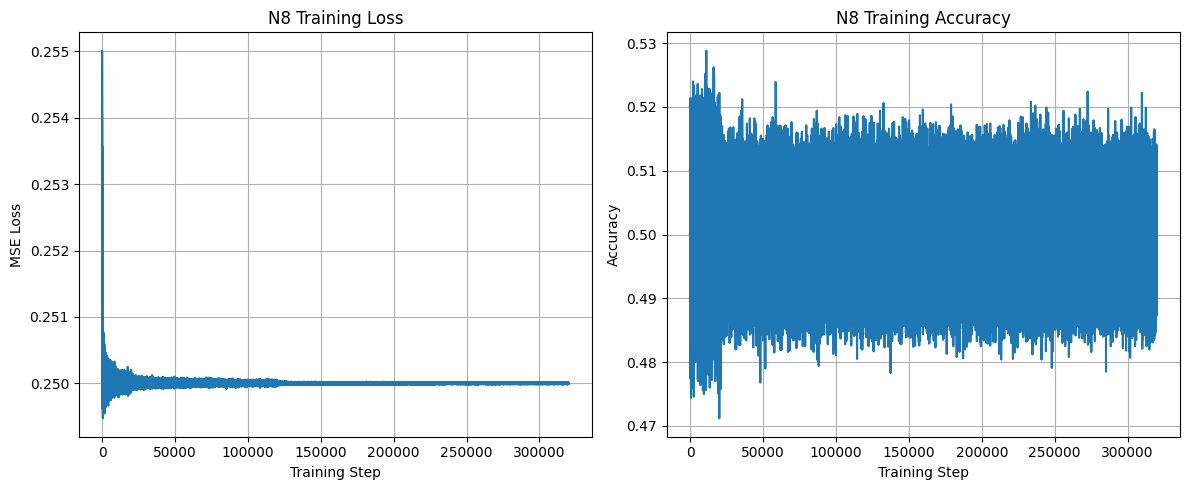

In [7]:
# Train N8 (no evaluation yet)
model_N8 = train_N8_from_N7(
    model_N7,
    save_path="light_models/dnd_speck32_r8_d1.pt"
)